In [23]:
import os.path

import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import seaborn as sns
from algbench import read_as_pandas
import matplotlib.ticker as ticker

import re
import json

font = {'family': 'serif', 'size': 11}
matplotlib.rc('font', **font)

matplotlib.rcParams['axes.prop_cycle'] = matplotlib.cycler(color=[
    "#089099",
    "#F0746E",
    "#27AE60",
])

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "Times New Roman"
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['figure.figsize'] = [9, 3.5]

In [7]:
paths = ['classical_qtg_comparison/small', 'classical_qtg_comparison/large']

ctg_results = pd.concat([read_as_pandas(f'results/ctg/{path}', lambda row: {
    'algorithm_human_readable': 'QTG',
    'elapsed_cycles': np.average(row['result']['elapsed_cycles']),
    'size': row['parameters']['args']['instance']['size'],
    'instance': row['parameters']['args']['instance']['name'],
    'qtg_estimate_cycles': np.average(
        [it * row['result']['qtg_cycles'] for it in row['result']['total_iterations']]),
    'objective_values': row['result']['objective_values'],
}) for path in paths if os.path.isdir(f'results/ctg/{path}/results')], ignore_index=True)

with open("cached/optimal_solutions.json", "r") as f:
    optimal_solutions = json.load(f)


def parse_combo(row):
    if row['parameters']['args']['solver'] != "combo":
        return None
    ctg_solution = ctg_results[ctg_results["instance"] == row['parameters']['args']['instance']['name']]
    assert len(ctg_solution) == 1, ctg_solution
    return {
        'algorithm': row['parameters']['args']['solver'],
        'instance': row['parameters']['args']['instance']['name'],
        'objective_value': row['result']['objective_value'],
        'elapsed_cycles': row['result']['elapsed_cycles'],
        'runtime': row['runtime'],
    }


combo_results = pd.concat([read_as_pandas(f'results/classical_benchmark/{path}', parse_combo) for path in paths],
                          ignore_index=True)

apply_g = lambda row: int(re.match(r'.+\_g\_([0-9]+)\_.+', row['instance']).group(1))
def g_group(row):
    if row['g'] == 2:
        return "$g=2$"
    elif row['g'] > 2 and row['g'] <= 6:
        return "$3 \\leq g \\leq 6$"
    return "$7 \\leq g \\leq 10$"

ctg_results['g'] = ctg_results.apply(apply_g, axis=1)
ctg_results['g_group'] = ctg_results.apply(g_group, axis=1)

In [13]:
ctg_results["success_probability"] = ctg_results.apply(
    lambda row: sum(
        [1 for obj in row['objective_values'] if
         obj == combo_results[combo_results["instance"] == row['instance']].iloc[0]["objective_value"]]) / len(
        row['objective_values']), axis=1)

In [30]:
def calculate_success_probability(row):
    success_probability = row['success_probability']

    combo_result = combo_results[combo_results["instance"] == row['instance']]
    assert len(combo_result) == 1
    combo_result = combo_result.iloc[0]

    new_success_prob = 1 - pow(1 - success_probability, combo_result['elapsed_cycles'] / row['qtg_estimate_cycles'])

    assert (combo_result['elapsed_cycles'] <= row['qtg_estimate_cycles'] and new_success_prob <= success_probability) or (
        (combo_result['elapsed_cycles'] >= row['qtg_estimate_cycles'] and new_success_prob >= success_probability)
    ), f"New success probability {new_success_prob} (old: {success_probability}) is not consistent with elapsed cycles {combo_result['elapsed_cycles']} and qtg estimate cycles {row['qtg_estimate_cycles']}"

    return new_success_prob

ctg_results["normalized_success_probability"] = ctg_results.apply(calculate_success_probability, axis=1)

In [21]:
ctg_results["normalized_success_probability"].mean(), ctg_results["normalized_success_probability"].std()

(0.7237179325738049, 0.4149549303967782)

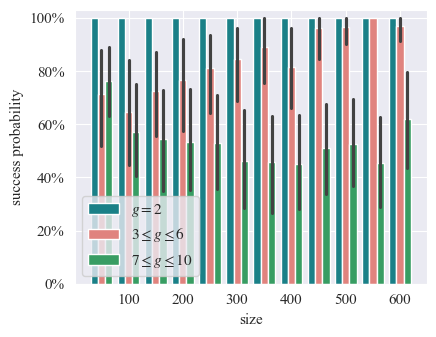

In [24]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))

sns.barplot(ctg_results,
            hue="g_group", dodge=True, x='size',
            hue_order=["$g=2$", "$3 \\leq g \\leq 6$", "$7 \\leq g \\leq 10$"],
            y='normalized_success_probability', ax=ax, native_scale=True)

ax.set_ylabel("success probability")
ax.yaxis.set_major_formatter(ticker.PercentFormatter(1))
ax.legend(loc="lower left").set_title(None)


ax.set_ylim(0, 1.03)

fig.tight_layout()
plt.savefig(f"out/13_normalized_success_prob_qtg.pdf", bbox_inches='tight')